All sheets loaded successfully!


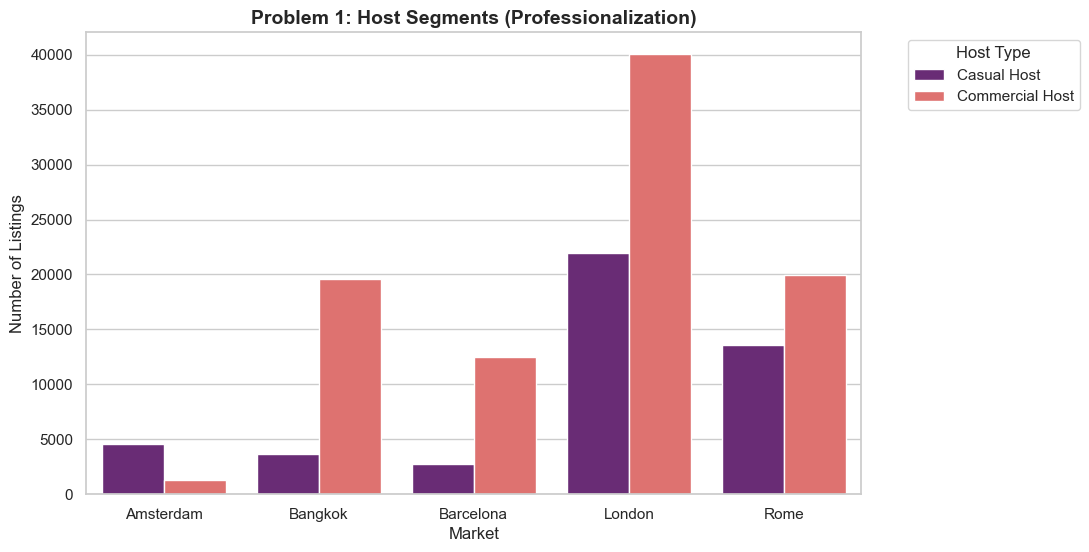

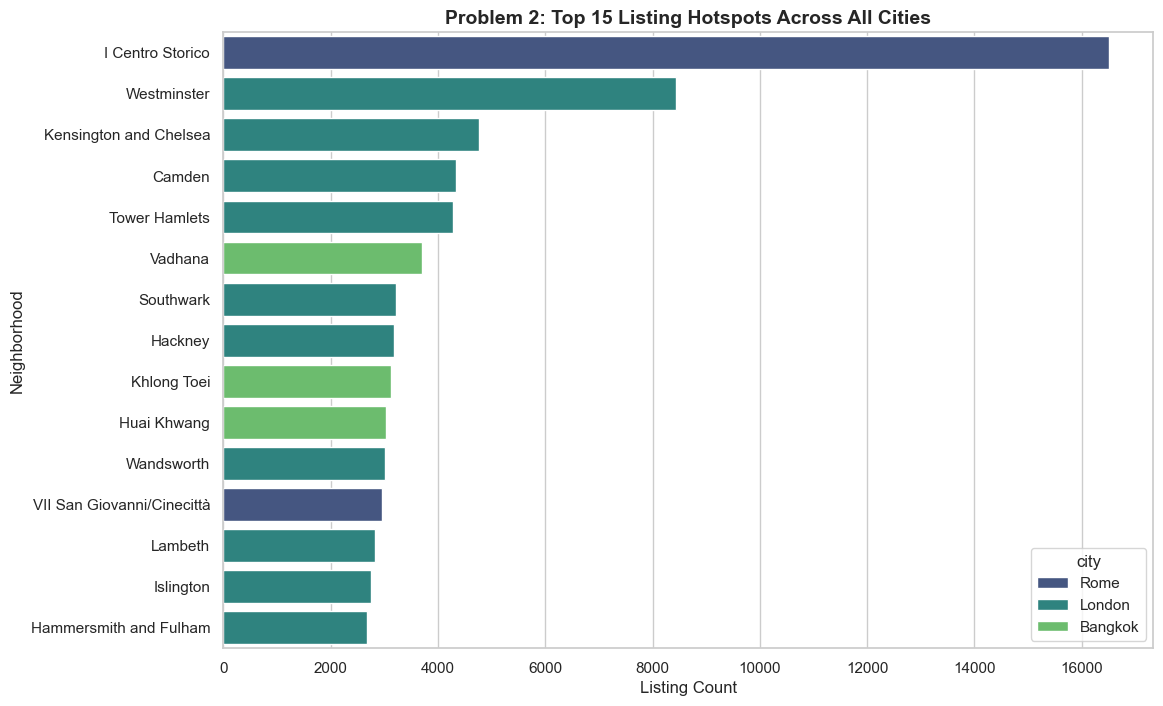

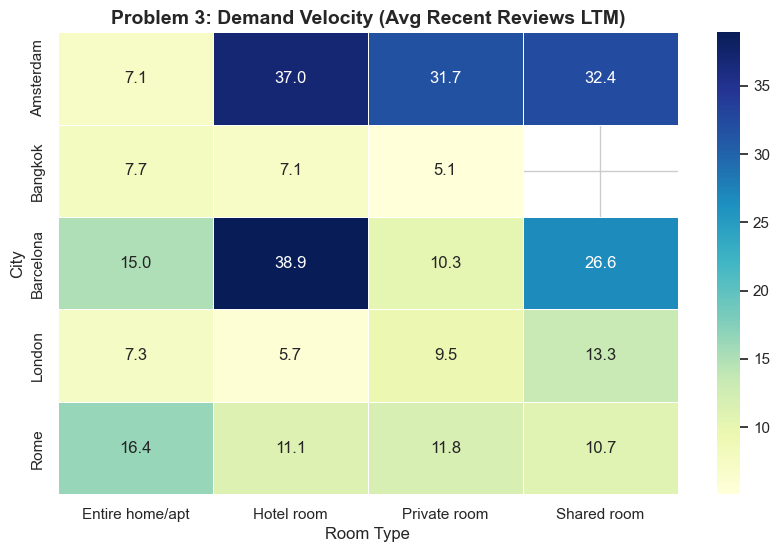

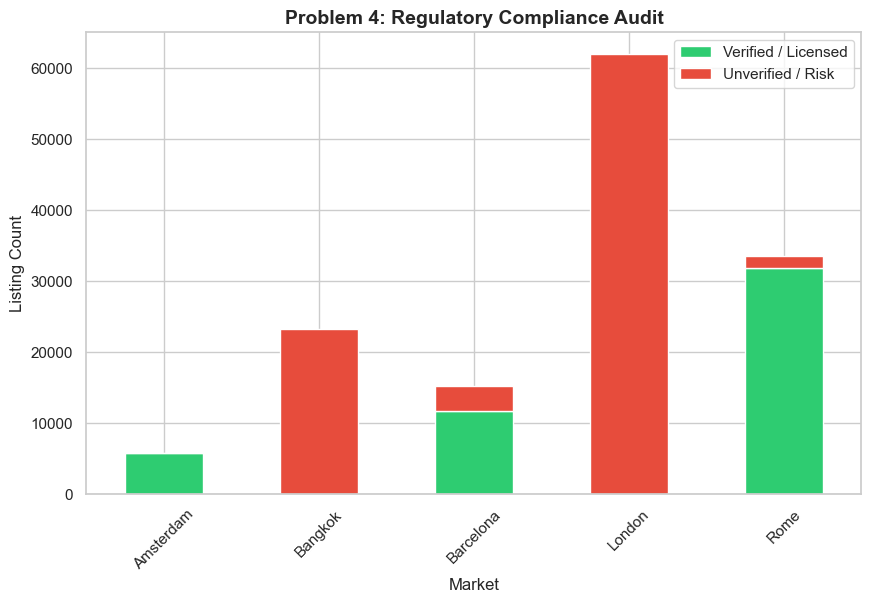

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. SETUP: Path to the folder in local system
file_path = os.path.expanduser("~/Desktop/P2/tables.xlsx")

# 2. LOAD DATA: Importing the 4 sheets
try:
    df_p1 = pd.read_excel(file_path, sheet_name='P1.Market Composition')
    df_p2 = pd.read_excel(file_path, sheet_name='P2. Neighborhood Hotspots')
    df_p3 = pd.read_excel(file_path, sheet_name='P3. Demand Velocity')
    df_p4 = pd.read_excel(file_path, sheet_name='P4. Regulatory Audit')
    print("All sheets loaded successfully!")
except Exception as e:
    print(f"Error: {e}")

# Styling for a professional Nielsen-style report
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 

# ---------------------------------------------------------
# VISUAL 1: Market Composition (Commercial vs Casual)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=df_p1, x='city', y='listing_count', hue='host_type', palette='magma')
plt.title('Problem 1: Host Segments (Professionalization)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Listings')
plt.xlabel('Market')
plt.legend(title='Host Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# ---------------------------------------------------------
# VISUAL 2: Neighborhood Hotspots (Top 15 Density)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
# Sorting to ensure the most dense areas are at the top
top_areas = df_p2.sort_values(by='total_listings', ascending=False).head(15)
sns.barplot(data=top_areas, x='total_listings', y='neighbourhood', hue='city', dodge=False, palette='viridis')
plt.title('Problem 2: Top 15 Listing Hotspots Across All Cities', fontsize=14, fontweight='bold')
plt.xlabel('Listing Count')
plt.ylabel('Neighborhood')
plt.show()

# ---------------------------------------------------------
# VISUAL 3: Demand Velocity (Heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Create pivot for the heatmap
demand_pivot = df_p3.pivot(index="city", columns="room_type", values="avg_recent_reviews")
sns.heatmap(demand_pivot, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=.5)
plt.title('Problem 3: Demand Velocity (Avg Recent Reviews LTM)', fontsize=14, fontweight='bold')
plt.ylabel('City')
plt.xlabel('Room Type')
plt.show()

# ---------------------------------------------------------
# VISUAL 4: Regulatory Risk Audit (Stacked Bar)
# ---------------------------------------------------------
# Setting index to city for the plotting function
df_p4_plot = df_p4.set_index('city')[['licensed count', 'unverified_count']]

# Plotting with Green for Licensed and Red for Unverified
ax = df_p4_plot.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Problem 4: Regulatory Compliance Audit', fontsize=14, fontweight='bold')
plt.ylabel('Listing Count')
plt.xlabel('Market')
plt.legend(['Verified / Licensed', 'Unverified / Risk'])
plt.xticks(rotation=45)
plt.show()